In [1]:
import hashlib
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
try:
    import open_clip
    from huggingface_hub import hf_hub_download
except ImportError:
    !pip install -q open_clip_torch huggingface_hub
    import open_clip
    from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

DATASET_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-tiles-sit2',
    INPUT_ROOT / 'geovision-tiles-sit2',
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[-1])

OUT_DIR = WORK_DIR / 'sit2_4_clip_sae_pdf_literal'
CKPT_DIR = OUT_DIR / 'checkpoints'
FIG_DIR = OUT_DIR / 'figures'
EMB_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, CKPT_DIR, FIG_DIR, EMB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TILES_PATH = DATASET_DIR / 'tiles_train.npz'
META_PATH = DATASET_DIR / 'tiles_meta.parquet'

BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12','SCL']
OPTICAL_BANDS = list(range(12))
OPTICAL_NAMES = BAND_NAMES[:12]
CLASES = ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']

REMOTECLIP_REPO = 'chendelong/RemoteCLIP'
REMOTECLIP_FILE = 'RemoteCLIP-ViT-B-32.pt'

BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0
EPOCHS = 20
PATIENCE = 4
LR = 2e-5
WEIGHT_DECAY = 0.2
LORA_RANK = 16
IMAGE_SIZE = 224

ALPHA_SAE = 0.10
LAMBDA_L1 = 1e-3
SAE_DIM = 512
PROJ_DIM = 256

PDF_THRESHOLDS = {
    'recall_at_1_min': 0.45,
    'recall_at_5_min': 0.70,
    'sparsity_visual_min': 0.70,
    'recon_visual_max': 0.05,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('DEVICE:', DEVICE)
print('DATASET_DIR:', DATASET_DIR)
print('OUT_DIR:', OUT_DIR)

DEVICE: cuda
DATASET_DIR: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
OUT_DIR: /kaggle/working/sit2_4_clip_sae_pdf_literal


In [4]:
data = np.load(TILES_PATH, allow_pickle=False)
if 'tiles' in data.files:
    tiles = data['tiles']
elif 'data' in data.files:
    tiles = data['data']
else:
    tiles = data[data.files[0]]

meta = pd.read_parquet(META_PATH).reset_index(drop=True)

print('Tiles:', tiles.shape, tiles.dtype)
print('Meta:', meta.shape)
print(meta['clase'].value_counts().sort_index())

Tiles: (5000, 13, 64, 64) float32
Meta: (5000, 22)
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
Name: count, dtype: int64


In [5]:
indices = np.arange(len(meta))
train_idx, temp_idx = train_test_split(indices, train_size=0.70, random_state=SEED, stratify=meta['clase'])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=meta.loc[temp_idx, 'clase'])

split_map = pd.Series(index=meta.index, dtype='object')
split_map.iloc[train_idx] = 'train'
split_map.iloc[val_idx] = 'val'
split_map.iloc[test_idx] = 'test'
meta['split_sit2_4'] = split_map
print(meta.groupby(['split_sit2_4', 'clase']).size().unstack(fill_value=0))
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

clase         contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split_sit2_4                                                                  
test                             150                     150            150   
train                            700                     700            700   
val                              150                     150            150   

clase         suelo_urbano  vegetacion_densa  
split_sit2_4                                  
test                   150               150  
train                  700               700  
val                    150               150  
Train/Val/Test: 3500 750 750


In [6]:
train_tiles = tiles[train_idx][:, OPTICAL_BANDS].astype(np.float32)
band_mean = train_tiles.mean(axis=(0, 2, 3))
band_std = train_tiles.std(axis=(0, 2, 3)) + 1e-6
with open(OUT_DIR / 'normalization_train_only.json', 'w') as f:
    json.dump({'band_names': OPTICAL_NAMES, 'mean': band_mean.tolist(), 'std': band_std.tolist()}, f, indent=2)
print('Band mean:', np.round(band_mean, 2))
print('Band std:', np.round(band_std, 2))

Band mean: [ 839.1   899.36 1078.99 1015.82 1391.8  2335.84 2736.64 2695.49 2944.17
 2917.74 2217.4  1610.46]
Band std: [ 773.9   846.42  794.67  858.79  776.23  740.14  890.85  919.14  948.44
 1014.35  812.18  956.35]


In [7]:
def train_quantiles(series, train_idx, qs=(0.25, 0.5, 0.75, 0.9)):
    values = series.iloc[train_idx].dropna().astype(float)
    return values.quantile(qs).to_dict()


S5P_QUANTILES = {col: train_quantiles(meta[col], train_idx) for col in ['no2', 'so2', 'o3']}
with open(OUT_DIR / 's5p_quantiles_train_only.json', 'w') as f:
    json.dump(S5P_QUANTILES, f, indent=2)


def level_from_quantiles(value, q):
    if pd.isna(value):
        return 'unknown'
    if value <= q[0.25]:
        return 'low'
    if value <= q[0.5]:
        return 'moderate'
    if value <= q[0.75]:
        return 'high'
    if value <= q[0.9]:
        return 'very high'
    return 'extreme'


def safe_month(value):
    if pd.isna(value):
        return -1
    text = str(value)
    parsed = pd.to_datetime(text, errors='coerce')
    if pd.isna(parsed) and len(text) >= 8 and text[:8].isdigit():
        parsed = pd.to_datetime(text[:8], format='%Y%m%d', errors='coerce')
    if pd.isna(parsed):
        return -1
    return int(parsed.month)


def month_period(value):
    month = safe_month(value)
    if month in [12, 1, 2, 3]:
        return 'dry season'
    if month in [4, 5, 10, 11]:
        return 'rain transition season'
    if month in [6, 7, 8, 9]:
        return 'mid-year season'
    return 'unknown season'


def zone_label(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'Cali metropolitan area'
    ns = 'northern' if lat >= 3.45 else 'southern'
    ew = 'eastern' if lon >= -76.50 else 'western'
    return f'{ns}-{ew} Cali metropolitan area'


def class_phrase(clase):
    phrases = {
        'contaminacion_alta_NO2': [
            'traffic-related nitrogen dioxide pollution pattern',
            'urban combustion and road corridor atmospheric signal',
            'anthropogenic NO2 hotspot over built-up land',
            'nitrogen dioxide anomaly associated with dense mobility',
            'high NO2 pseudo-label in an urban atmospheric context',
        ],
        'contaminacion_alta_SO2': [
            'industrial sulfur dioxide plume pattern',
            'SO2 signal associated with combustion and industrial activity',
            'sulfur dioxide anomaly near an industrial corridor',
            'elevated SO2 pseudo-label in a regional emission context',
            'industrial atmospheric loading dominated by sulfur dioxide',
        ],
        'ozono_anomalo': [
            'photochemical ozone anomaly under stable atmospheric conditions',
            'regional O3 anomaly linked to secondary pollutant formation',
            'ozone-dominated atmospheric regime over the urban footprint',
            'anomalous O3 pseudo-label in a dry or transitional season',
            'elevated ozone pattern with diffuse regional influence',
        ],
        'vegetacion_densa': [
            'dense vegetation cover with strong near infrared response',
            'healthy vegetation or cropland dominated Sentinel-2 tile',
            'green canopy surface with high photosynthetic activity',
            'vegetated landscape with low built-up influence',
            'dense biomass cover in the Cali metropolitan surroundings',
        ],
        'suelo_urbano': [
            'urban built-up surface with sparse vegetation',
            'impervious urban land cover with road and building patterns',
            'dense city fabric with low vegetation response',
            'built environment dominated Sentinel-2 tile',
            'urban surface pattern near populated areas',
        ],
    }
    return phrases[clase]


def make_captions(row):
    no2_level = level_from_quantiles(row.get('no2'), S5P_QUANTILES['no2'])
    so2_level = level_from_quantiles(row.get('so2'), S5P_QUANTILES['so2'])
    o3_level = level_from_quantiles(row.get('o3'), S5P_QUANTILES['o3'])
    ndvi_level = level_from_quantiles(row.get('ndvi'), {0.25: 0.25, 0.5: 0.50, 0.75: 0.70, 0.9: 0.85})
    ndbi_level = level_from_quantiles(row.get('ndbi'), {0.25: -0.15, 0.5: 0.00, 0.75: 0.15, 0.9: 0.30})
    aod_level = level_from_quantiles(row.get('modis_AOD_047'), {0.25: 0.05, 0.5: 0.12, 0.75: 0.22, 0.9: 0.35})
    blh_level = level_from_quantiles(row.get('era5_BLH'), {0.25: 150, 0.5: 400, 0.75: 800, 0.9: 1200})
    temp_level = level_from_quantiles(row.get('era5_T2m'), {0.25: 295, 0.5: 300, 0.75: 305, 0.9: 310})
    period = month_period(row.get('time_s2'))
    zone = zone_label(row.get('lat'), row.get('lon'))
    phrases = class_phrase(row['clase'])
    return [
        f'Sentinel-2 tile over the {zone} during the {period}. The scene shows {ndvi_level} NDVI, {ndbi_level} NDBI, and {phrases[0]}.',
        f'Remote sensing view of Cali with {phrases[1]}. Atmospheric categories are NO2 {no2_level}, SO2 {so2_level}, and O3 {o3_level}.',
        f'A multispectral urban-environment tile with {ndvi_level} vegetation signal, {ndbi_level} built-up index, {aod_level} aerosol loading, and {phrases[2]}.',
        f'The tile belongs to the {period} and has {blh_level} boundary layer height, {temp_level} air temperature, and {phrases[3]}.',
        f'GeoVision caption for a Cali Sentinel-2 tile: {phrases[4]}, with discretized atmospheric context NO2 {no2_level}, SO2 {so2_level}, O3 {o3_level}.',
    ]


caption_lists = meta.apply(make_captions, axis=1)
for i in range(5):
    meta[f'caption_{i}'] = caption_lists.apply(lambda captions: captions[i])
meta['texto_pdf_literal'] = meta['caption_0']

all_captions = [caption for captions in caption_lists for caption in captions]
text_stats = {
    'n_images': int(len(meta)),
    'captions_per_image': 5,
    'n_captions': int(len(all_captions)),
    'n_unique_captions': int(len(set(all_captions))),
    'unique_caption_ratio': float(len(set(all_captions)) / len(all_captions)),
    'unique_first_caption_ratio': float(meta['caption_0'].nunique() / len(meta)),
}
with open(OUT_DIR / 'text_stats.json', 'w') as f:
    json.dump(text_stats, f, indent=2)
print(json.dumps(text_stats, indent=2))
print(meta[['clase', 'caption_0', 'caption_1']].head())

{
  "n_images": 5000,
  "captions_per_image": 5,
  "n_captions": 25000,
  "n_unique_captions": 633,
  "unique_caption_ratio": 0.02532,
  "unique_first_caption_ratio": 0.0708
}
                    clase                                          caption_0  \
0  contaminacion_alta_NO2  Sentinel-2 tile over the northern-eastern Cali...   
1  contaminacion_alta_NO2  Sentinel-2 tile over the northern-eastern Cali...   
2  contaminacion_alta_NO2  Sentinel-2 tile over the southern-western Cali...   
3  contaminacion_alta_NO2  Sentinel-2 tile over the southern-western Cali...   
4  contaminacion_alta_NO2  Sentinel-2 tile over the northern-western Cali...   

                                           caption_1  
0  Remote sensing view of Cali with urban combust...  
1  Remote sensing view of Cali with urban combust...  
2  Remote sensing view of Cali with urban combust...  
3  Remote sensing view of Cali with urban combust...  
4  Remote sensing view of Cali with urban combust...  


In [8]:
class TilesClipDataset(Dataset):
    def __init__(self, tiles, meta, indices, band_mean, band_std, train=False):
        self.tiles = tiles
        self.meta = meta.reset_index(drop=True)
        self.indices = np.asarray(indices)
        self.band_mean = torch.tensor(band_mean, dtype=torch.float32).view(12, 1, 1)
        self.band_std = torch.tensor(band_std, dtype=torch.float32).view(12, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        x = torch.tensor(self.tiles[idx, OPTICAL_BANDS].astype(np.float32))
        x = (x - self.band_mean) / self.band_std
        x = torch.clamp(x, -3.0, 3.0)
        if self.train:
            if torch.rand(()) < 0.5:
                x = torch.flip(x, dims=[2])
            k = int(torch.randint(0, 4, ()).item())
            x = torch.rot90(x, k, dims=[1, 2])
        x = F.interpolate(x.unsqueeze(0), size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False).squeeze(0)
        row = self.meta.loc[idx]
        captions = [row[f'caption_{j}'] for j in range(5)]
        text = random.choice(captions) if self.train else captions[0]
        return {'image': x, 'text': text, 'captions': captions, 'label': row['clase'], 'index': int(idx)}


def collate_fn(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        'text': [b['text'] for b in batch],
        'captions': [b['captions'] for b in batch],
        'label': [b['label'] for b in batch],
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
    }

train_ds = TilesClipDataset(tiles, meta, train_idx, band_mean, band_std, train=True)
val_ds = TilesClipDataset(tiles, meta, val_idx, band_mean, band_std, train=False)
test_ds = TilesClipDataset(tiles, meta, test_idx, band_mean, band_std, train=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Effective batch size:', BATCH_SIZE * GRAD_ACCUM_STEPS)

Dataset sizes: 3500 750 750
Effective batch size: 128


In [9]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, rank: int = 16):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))

    @property
    def weight(self):
        return self.linear.weight

    @weight.setter
    def weight(self, w):
        self.linear.weight = w

    @property
    def bias(self):
        return self.linear.bias

    @bias.setter
    def bias(self, b):
        self.linear.bias = b

    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)


def aplicar_lora(module, rank=16, nombres_lora=None):
    if nombres_lora is None:
        nombres_lora = {'out_proj', 'c_fc', 'c_proj'}
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in nombres_lora:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank, nombres_lora)


class SparseAutoencoder(nn.Module):
    def __init__(self, dim=512, hidden=512):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU())
        self.decoder = nn.Linear(hidden, dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        recon = F.mse_loss(x_hat, x)
        sparsity = (z.abs() < 0.01).float().mean()
        l1 = z.abs().mean()
        return z, x_hat, recon, sparsity, l1


class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim))

    def forward(self, x):
        return self.net(x)

In [10]:
ckpt_path = hf_hub_download(repo_id=REMOTECLIP_REPO, filename=REMOTECLIP_FILE)
remote_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(remote_ckpt, strict=False)
print(f'Modelo base cargado: {REMOTECLIP_FILE}')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Modelo base cargado: RemoteCLIP-ViT-B-32.pt


In [11]:
for p in clip_model.parameters():
    p.requires_grad = False

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=LORA_RANK)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=LORA_RANK)

for name, p in clip_model.named_parameters():
    if any(k in name for k in ['text_projection', 'ln_final', 'ln_post', 'logit_scale']):
        p.requires_grad = True
    if 'visual.proj' in name:
        p.requires_grad = True

orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size, stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = OPTICAL_NAMES.index('B4')
    idx_g = OPTICAL_NAMES.index('B3')
    idx_b = OPTICAL_NAMES.index('B2')
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / 12)
    new_conv.weight.copy_(w_new)
clip_model.visual.conv1 = new_conv

clip_model = clip_model.to(DEVICE)
sae_img = SparseAutoencoder(512, SAE_DIM).to(DEVICE)
sae_txt = SparseAutoencoder(512, SAE_DIM).to(DEVICE)
proj_img = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)
proj_txt = ProjectionHead(SAE_DIM, PROJ_DIM).to(DEVICE)

tokenizer = open_clip.get_tokenizer('ViT-B-32')
trainable_params = ([p for p in clip_model.parameters() if p.requires_grad]
                    + list(sae_img.parameters()) + list(sae_txt.parameters())
                    + list(proj_img.parameters()) + list(proj_txt.parameters()))
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print('Trainable params:', sum(p.numel() for p in trainable_params)/1e6, 'M')

Trainable params: 12.883969 M


In [12]:
def info_nce_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * image_features @ text_features.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_i + loss_t), logits


def apply_sae_to_image(img_base):
    z_img, _, recon_img, sparsity_img, l1_img = sae_img(img_base)
    emb_img = proj_img(z_img)
    sae_img_loss = recon_img + LAMBDA_L1 * l1_img
    return emb_img, {'recon_img': recon_img, 'sparsity_img': sparsity_img, 'sae_img_loss': sae_img_loss}


def apply_sae_to_text(txt_base):
    z_txt, _, recon_txt, sparsity_txt, l1_txt = sae_txt(txt_base)
    emb_txt = proj_txt(z_txt)
    sae_txt_loss = recon_txt + LAMBDA_L1 * l1_txt
    return emb_txt, {'recon_txt': recon_txt, 'sparsity_txt': sparsity_txt, 'sae_txt_loss': sae_txt_loss}


def encode_batch(model, images, texts):
    images = images.to(DEVICE, non_blocking=True)
    tokens = tokenizer(texts).to(DEVICE)
    img_base = model.encode_image(images)
    txt_base = model.encode_text(tokens)
    emb_img, img_aux = apply_sae_to_image(img_base)
    emb_txt, txt_aux = apply_sae_to_text(txt_base)
    aux = {**img_aux, **txt_aux}
    return emb_img, emb_txt, aux


@torch.no_grad()
def encode_text_list(model, texts, batch_size=128):
    embs, aux_rows = [], []
    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        tokens = tokenizer(chunk).to(DEVICE)
        txt_base = model.encode_text(tokens)
        emb_txt, aux = apply_sae_to_text(txt_base)
        embs.append(emb_txt.detach().cpu())
        aux_rows.append({k: v.item() for k, v in aux.items()})
    aux_mean = {k: float(np.mean([row[k] for row in aux_rows])) for k in aux_rows[0]}
    return torch.cat(embs), aux_mean

In [13]:
def alpha_for_epoch(epoch):
    return min(ALPHA_SAE, ALPHA_SAE * epoch / 5)


def run_epoch(loader, epoch, train=False):
    clip_model.train(train)
    sae_img.train(train)
    sae_txt.train(train)
    proj_img.train(train)
    proj_txt.train(train)
    totals = {k: 0.0 for k in ['total','clip','recon_img','recon_txt','sparsity_img','sparsity_txt']}
    steps = 0
    alpha_epoch = alpha_for_epoch(epoch)
    if train:
        optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(tqdm(loader, leave=False), start=1):
        emb_img, emb_txt, aux = encode_batch(clip_model, batch['image'], batch['text'])
        loss_clip, _ = info_nce_loss(emb_img, emb_txt, clip_model.logit_scale)
        loss = loss_clip + alpha_epoch * (aux['sae_img_loss'] + aux['sae_txt_loss'])
        if train:
            (loss / GRAD_ACCUM_STEPS).backward()
            if step % GRAD_ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
        totals['total'] += loss.item()
        totals['clip'] += loss_clip.item()
        totals['recon_img'] += aux['recon_img'].item()
        totals['recon_txt'] += aux['recon_txt'].item()
        totals['sparsity_img'] += aux['sparsity_img'].item()
        totals['sparsity_txt'] += aux['sparsity_txt'].item()
        steps += 1
    if train and steps % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    out = {k: v / max(steps, 1) for k, v in totals.items()}
    out['alpha_sae'] = alpha_epoch
    return out

best_val = float('inf')
best_epoch = 0
patience_count = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(train_loader, epoch, train=True)
    with torch.no_grad():
        val_m = run_epoch(val_loader, epoch, train=False)
    scheduler.step()
    row = {
        'epoch': epoch,
        **{f'train_{k}': v for k, v in train_m.items()},
        **{f'val_{k}': v for k, v in val_m.items()},
        'logit_scale': float(clip_model.logit_scale.detach().exp().cpu().clamp(max=100)),
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    print(f"Epoch {epoch:02d} | alpha={row['train_alpha_sae']:.3f} train={row['train_total']:.4f} clip={row['train_clip']:.4f} rec_img={row['train_recon_img']:.4f} sp={row['train_sparsity_img']:.3f} | val={row['val_total']:.4f} clip={row['val_clip']:.4f} rec_img={row['val_recon_img']:.4f} sp={row['val_sparsity_img']:.3f}")
    if row['val_total'] < best_val:
        best_val = row['val_total']
        best_epoch = epoch
        patience_count = 0
        torch.save({
            'clip': clip_model.state_dict(), 'sae_img': sae_img.state_dict(), 'sae_txt': sae_txt.state_dict(),
            'proj_img': proj_img.state_dict(), 'proj_txt': proj_txt.state_dict(), 'epoch': epoch, 'val_loss': best_val,
            'band_mean': band_mean.tolist(), 'band_std': band_std.tolist(),
            'split': {'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist()},
            'alpha_sae': ALPHA_SAE, 'lambda_l1': LAMBDA_L1, 's5p_quantiles': S5P_QUANTILES,
            'captions_per_image': 5, 'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
        }, CKPT_DIR / 'clip_sae_pdf_literal_best.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print('Early stopping en epoch', epoch)
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / 'train_log.csv', index=False)
print('Mejor epoch:', best_epoch, 'val_loss:', best_val)

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01 | alpha=0.020 train=4.4623 clip=4.4541 rec_img=0.2607 sp=0.474 | val=3.8689 clip=3.8608 rec_img=0.2663 sp=0.476


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 19 | alpha=0.100 train=3.2465 clip=3.2275 rec_img=0.1156 sp=0.484 | val=2.7546 clip=2.7370 rec_img=0.1147 sp=0.484


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 20 | alpha=0.100 train=3.2628 clip=3.2438 rec_img=0.1153 sp=0.484 | val=2.7543 clip=2.7366 rec_img=0.1150 sp=0.484
Mejor epoch: 20 val_loss: 2.754274308681488


In [14]:
best_ckpt = torch.load(CKPT_DIR / 'clip_sae_pdf_literal_best.pt', map_location=DEVICE, weights_only=False)
clip_model.load_state_dict(best_ckpt['clip'])
sae_img.load_state_dict(best_ckpt['sae_img'])
sae_txt.load_state_dict(best_ckpt['sae_txt'])
proj_img.load_state_dict(best_ckpt['proj_img'])
proj_txt.load_state_dict(best_ckpt['proj_txt'])
clip_model.eval(); sae_img.eval(); sae_txt.eval(); proj_img.eval(); proj_txt.eval()
print('Checkpoint cargado:', best_ckpt['epoch'], best_ckpt['val_loss'])

Checkpoint cargado: 20 2.754274308681488


In [15]:
@torch.no_grad()
def collect_embeddings(loader):
    image_embs, labels, indices_out, all_captions, caption_owner = [], [], [], [], []
    aux_totals = {k: 0.0 for k in ['recon_img','sparsity_img']}
    steps = 0
    image_counter = 0
    for batch in tqdm(loader, desc='Embeddings', leave=False):
        images = batch['image'].to(DEVICE, non_blocking=True)
        img_base = clip_model.encode_image(images)
        emb_img, img_aux = apply_sae_to_image(img_base)
        image_embs.append(emb_img.detach().cpu())
        labels.extend(batch['label'])
        indices_out.extend(batch['index'].tolist())
        for captions in batch['captions']:
            all_captions.extend(captions)
            caption_owner.extend([image_counter] * len(captions))
            image_counter += 1
        aux_totals['recon_img'] += img_aux['recon_img'].item()
        aux_totals['sparsity_img'] += img_aux['sparsity_img'].item()
        steps += 1
    text_embs, text_aux = encode_text_list(clip_model, all_captions)
    aux = {k: v / max(steps, 1) for k, v in aux_totals.items()}
    aux.update(text_aux)
    return {
        'image': torch.cat(image_embs), 'text': text_embs, 'label': np.array(labels),
        'index': np.array(indices_out), 'captions': all_captions, 'caption_owner': torch.tensor(caption_owner),
        'aux': aux,
    }

train_emb = collect_embeddings(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn))
val_emb = collect_embeddings(val_loader)
test_emb = collect_embeddings(test_loader)
print('Embeddings:', train_emb['image'].shape, val_emb['image'].shape, val_emb['text'].shape, test_emb['image'].shape, test_emb['text'].shape)
print('Aux test:', test_emb['aux'])

Embeddings:   0%|          | 0/55 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings: torch.Size([3500, 256]) torch.Size([750, 256]) torch.Size([3750, 256]) torch.Size([750, 256]) torch.Size([3750, 256])
Aux test: {'recon_img': 0.11763000674545765, 'sparsity_img': 0.48269365976254147, 'recon_txt': 0.07384551589687666, 'sparsity_txt': 0.5104429284731548, 'sae_txt_loss': 0.07392693758010864}


In [16]:
def recall_at_k_multicaption(image_embeddings, text_embeddings, caption_owner, ks=(1, 5, 10)):
    image_embeddings = F.normalize(image_embeddings, dim=-1)
    text_embeddings = F.normalize(text_embeddings, dim=-1)
    sims = image_embeddings @ text_embeddings.T
    out = {}
    for k in ks:
        topk = sims.topk(min(k, sims.shape[1]), dim=1).indices
        owners = caption_owner[topk]
        targets = torch.arange(sims.shape[0])[:, None]
        out[f'recall@{k}'] = (owners == targets).any(dim=1).float().mean().item()
    return out

retrieval_val = recall_at_k_multicaption(val_emb['image'], val_emb['text'], val_emb['caption_owner'])
retrieval_test = recall_at_k_multicaption(test_emb['image'], test_emb['text'], test_emb['caption_owner'])
print('Retrieval val:', retrieval_val)
print('Retrieval test:', retrieval_test)

success_pdf = {
    'recall_at_1_min': retrieval_test['recall@1'] >= PDF_THRESHOLDS['recall_at_1_min'],
    'recall_at_5_min': retrieval_test['recall@5'] >= PDF_THRESHOLDS['recall_at_5_min'],
    'sparsity_visual_min': float(test_emb['aux']['sparsity_img']) >= PDF_THRESHOLDS['sparsity_visual_min'],
    'recon_visual_max': float(test_emb['aux']['recon_img']) <= PDF_THRESHOLDS['recon_visual_max'],
}
print('Success PDF:', success_pdf)

Retrieval val: {'recall@1': 0.012000000104308128, 'recall@5': 0.07466666400432587, 'recall@10': 0.1613333374261856}
Retrieval test: {'recall@1': 0.01066666655242443, 'recall@5': 0.07599999755620956, 'recall@10': 0.14000000059604645}
Success PDF: {'recall_at_1_min': False, 'recall_at_5_min': False, 'sparsity_visual_min': False, 'recon_visual_max': False}


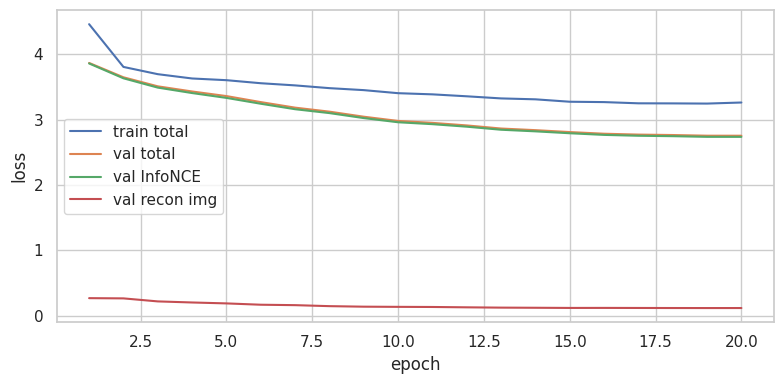

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
if len(history_df):
    ax.plot(history_df['epoch'], history_df['train_total'], label='train total')
    ax.plot(history_df['epoch'], history_df['val_total'], label='val total')
    ax.plot(history_df['epoch'], history_df['val_clip'], label='val InfoNCE')
    ax.plot(history_df['epoch'], history_df['val_recon_img'], label='val recon img')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'training_curves.png', dpi=160)
plt.show()

In [18]:
ckpt_path = CKPT_DIR / 'clip_sae_pdf_literal_best.pt'
md5 = hashlib.md5(ckpt_path.read_bytes()).hexdigest()
metrics = {
    'experiment': 'sit2_4_clip_sae_pdf_literal',
    'pdf_literal': True,
    'no_raw_s5p_values_in_text': True,
    'captions_per_image': 5,
    'caption_language': 'English',
    'multi_caption_recall': True,
    'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
    'no_s5p_numeric_input': True,
    'split': '70/15/15 stratified',
    'normalization': 'train only',
    'alpha_sae': ALPHA_SAE,
    'lambda_l1': LAMBDA_L1,
    'sae_dim': SAE_DIM,
    'proj_dim': PROJ_DIM,
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val),
    'retrieval_val': retrieval_val,
    'retrieval_test': retrieval_test,
    'sae_aux_test': test_emb['aux'],
    'pdf_thresholds': PDF_THRESHOLDS,
    'success_pdf': success_pdf,
    'text_stats': text_stats,
    'checkpoint_md5': md5,
}
with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'checkpoint.md5', 'w') as f:
    f.write(md5)
np.savez_compressed(EMB_DIR / 'test_embeddings_sae_pdf_literal.npz', image=test_emb['image'].numpy(), text=test_emb['text'].numpy(), caption_owner=test_emb['caption_owner'].numpy(), label=test_emb['label'], index=test_emb['index'])
print(json.dumps(metrics, indent=2))

{
  "experiment": "sit2_4_clip_sae_pdf_literal",
  "pdf_literal": true,
  "no_raw_s5p_values_in_text": true,
  "captions_per_image": 5,
  "caption_language": "English",
  "multi_caption_recall": true,
  "effective_batch_size": 128,
  "no_s5p_numeric_input": true,
  "split": "70/15/15 stratified",
  "normalization": "train only",
  "alpha_sae": 0.1,
  "lambda_l1": 0.001,
  "sae_dim": 512,
  "proj_dim": 256,
  "best_epoch": 20,
  "best_val_loss": 2.754274308681488,
  "retrieval_val": {
    "recall@1": 0.012000000104308128,
    "recall@5": 0.07466666400432587,
    "recall@10": 0.1613333374261856
  },
  "retrieval_test": {
    "recall@1": 0.01066666655242443,
    "recall@5": 0.07599999755620956,
    "recall@10": 0.14000000059604645
  },
  "sae_aux_test": {
    "recon_img": 0.11763000674545765,
    "sparsity_img": 0.48269365976254147,
    "recon_txt": 0.07384551589687666,
    "sparsity_txt": 0.5104429284731548,
    "sae_txt_loss": 0.07392693758010864
  },
  "pdf_thresholds": {
    "recall_a